# 03 Machine Learning Analysis on AI Job Market Data

This notebook adds a clean machine learning analysis layer on top of the final AI job market dataset.

The goal is not to build a perfect predictive system. The goal is to apply a professional, readable data science workflow:

1. Load the cleaned dataset
2. Prepare the data for machine learning
3. Explore salaries before modeling
4. Build simple baseline models
5. Train regression and classification models
6. Compare results carefully
7. Save outputs for the portfolio

Important note: the models in this notebook are exploratory. They help understand patterns in the dataset, but they should not be interpreted as causal explanations of salary or job market behavior.

## 1. Import Libraries and Settings

We start by importing common data science libraries.

The notebook uses only standard tools that are usually available in Anaconda or easy to install:

- `pandas` and `numpy` for data manipulation
- `matplotlib` and `seaborn` for visualization
- `sklearn` for machine learning
- `pathlib` for clean file paths on Windows
- `ast` to safely parse list-like strings from CSV files

In [1]:
# Core libraries
from pathlib import Path
import ast
import warnings

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    hamming_loss
)

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

# Text and clustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# Sparse matrix tools
from scipy.sparse import hstack, csr_matrix

# Optional: save models
import joblib

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Project Paths

The dataset is stored in the existing project folder.

We also create output folders for tables, figures, and models. This keeps the notebook clean and makes the project easier to present in a portfolio or GitHub repository.

In [2]:
DATA_DIR = Path(
    r"C:\Users\jerem\job_analysis\2026_ai_job_market_analysis"
)

DATASET_PATH = (
    DATA_DIR
    / "data"
    / "JobMarket2026"
    / "final_ai_job_market_dataset.csv"
)

OUTPUT_DIR = DATA_DIR / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset path:", DATASET_PATH)
print("Tables folder:", TABLE_DIR)
print("Figures folder:", FIGURE_DIR)
print("Models folder:", MODEL_DIR)

Dataset path: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\data\JobMarket2026\final_ai_job_market_dataset.csv
Tables folder: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\tables
Figures folder: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\figures
Models folder: C:\Users\jerem\job_analysis\2026_ai_job_market_analysis\outputs\models


## 2. Load the Final Dataset

We load the final cleaned dataset created in the previous notebook.

Two copies are created:

- `df_raw`: the original loaded data, kept unchanged
- `df_ml`: a working copy used for machine learning preparation

In [3]:
# Load the final dataset

df_raw = pd.read_csv(DATASET_PATH)

# Create a working copy for machine learning

df_ml = df_raw.copy()

print("Raw dataset shape:", df_raw.shape)
print("ML working dataset shape:", df_ml.shape)

Raw dataset shape: (5773, 48)
ML working dataset shape: (5773, 48)


In [4]:
# Display columns

df_ml.columns.tolist()

['job_posting_id',
 'job_title',
 'job_title_original',
 'company',
 'country',
 'city',
 'city_clean',
 'remote_type',
 'experience_level',
 'source',
 'salary_min',
 'salary_max',
 'salary_avg',
 'currency',
 'posted_date',
 'year',
 'month',
 'year_month',
 'job_description',
 'description_length',
 'description_truncated',
 'normalized_title',
 'title_similarity',
 'normalization_method',
 'esco_occupation',
 'required_skills',
 'original_skills_list',
 'has_original_skills',
 'n_original_skills',
 'inferred_skills_knn',
 'completed_skills_list',
 'skill_inference_method',
 'has_section9_completed_skills',
 'n_section9_completed_skills',
 'needs_llm_validation',
 'llm_status',
 'llm_validated_skills_list',
 'llm_removed_skills_list',
 'llm_skill_reasons',
 'llm_keep_rate',
 'recommended_skills_list',
 'recommended_skills',
 'final_recommended_skills',
 'recommended_skill_source',
 'final_skill_source',
 'has_recommended_skills',
 'n_recommended_skills',
 'n_final_recommended_skills

In [5]:
# Display first rows

df_ml.head()

,job_posting_id,job_title,job_title_original,company,country,city,city_clean,remote_type,experience_level,source,salary_min,salary_max,salary_avg,currency,posted_date,year,month,year_month,job_description,description_length,description_truncated,normalized_title,title_similarity,normalization_method,esco_occupation,required_skills,original_skills_list,has_original_skills,n_original_skills,inferred_skills_knn,completed_skills_list,skill_inference_method,has_section9_completed_skills,n_section9_completed_skills,needs_llm_validation,llm_status,llm_validated_skills_list,llm_removed_skills_list,llm_skill_reasons,llm_keep_rate,recommended_skills_list,recommended_skills,final_recommended_skills,recommended_skill_source,final_skill_source,has_recommended_skills,n_recommended_skills,n_final_recommended_skills
0,1,AI Engineer,AI Engineer,Jobot,United States,Mount Carmel,mount carmel,Unspecified,Lead,Adzuna,160000.0,160000.0,160000.0,USD,2026-02-16,2026.0,2.0,2026-02,RAG - Vector Databases - Cloud - AI/ML This Jobot Job is hosted by: Chuck Wirtz Are you a fit? Easy Apply now by cli...,500,True,AI Engineer,1.0,rule,artificial intelligence engineer,RAG,['rag'],True,1,[],['rag'],original,True,1,False,not_validated,[],[],{},0.000000,['rag'],rag,rag,original,original,True,1,1
1,2,AI Engineer,AI Engineer,Jobot,United States,The Gap,the gap,Unspecified,Lead,Adzuna,175000.0,175000.0,175000.0,USD,2026-02-16,2026.0,2.0,2026-02,RAG - Vector Databases - Cloud - AI/ML This Jobot Job is hosted by: Chuck Wirtz Are you a fit? Easy Apply now by cli...,500,True,AI Engineer,1.0,rule,artificial intelligence engineer,RAG,['rag'],True,1,[],['rag'],original,True,1,False,not_validated,[],[],{},0.000000,['rag'],rag,rag,original,original,True,1,1
2,3,AI Engineer,AI Engineer,Jobot,United States,Nashville,nashville,Unspecified,Lead,Adzuna,218000.0,218000.0,218000.0,USD,2026-02-16,2026.0,2.0,2026-02,RAG - Vector Databases - Cloud - AI/ML This Jobot Job is hosted by: Chuck Wirtz Are you a fit? Easy Apply now by cli...,500,True,AI Engineer,1.0,rule,artificial intelligence engineer,RAG,['rag'],True,1,[],['rag'],original,True,1,False,not_validated,[],[],{},0.000000,['rag'],rag,rag,original,original,True,1,1
3,4,Frontend/AI Engineer,Frontend/AI Engineer,Jobot,United States,New York City,new york city,Unspecified,Mid-level,Adzuna,112000.0,112000.0,112000.0,USD,2026-02-16,2026.0,2.0,2026-02,Manufacturing Company looking for Business System Analyst This Jobot Job is hosted by: John Erwin Are you a fit? Eas...,500,True,AI Engineer,1.0,rule,artificial intelligence engineer,NaN,[],False,0,"['rag', 'aws', 'azure', 'computer vision', 'gcp', 'hadoop', 'nlp', 'python']","['rag', 'aws', 'azure', 'computer vision', 'gcp', 'hadoop', 'nlp', 'python']",knn_inference,True,8,True,ok,"['aws', 'azure', 'computer vision', 'nlp', 'python']","['gcp', 'hadoop', 'rag']",{},0.625000,"['aws', 'azure', 'computer vision', 'nlp', 'python']","aws, azure, computer vision, nlp, python","aws, azure, computer vision, nlp, python",llm_validated_with_rescue,llm_validated_with_rescue,True,5,5
4,5,AI Engineering Lead,AI Engineering Lead,Jobot,United States,Irvine,irvine,Unspecified,Senior,Adzuna,92000.0,92000.0,92000.0,USD,2026-02-16,2026.0,2.0,2026-02,Lead Financial Insights and Reporting as a Senior Accountant in a Dynamic Energy-Focused Environment This Jobot Job ...,500,True,AI Engineer,1.0,rule,artificial intelligence engineer,NaN,[],False,0,"['rag', 'fine-tuning', 'azure']","['rag', 'fine-tuning', 'azure']",knn_inference,True,3,True,ok,['azure'],"['fine-tuning', 'rag']",{},0.333333,['azure'],azure,azure,llm_validated_with_rescue,llm_validated_with_rescue,True,1,1


### Missing Values Summary

Before modeling, it is important to understand how much data is missing.

Missing values can strongly affect machine learning models, especially salary models where many job postings do not publish compensation.

In [6]:
missing_summary = (
    df_ml.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df_ml) * 100
).round(2)

missing_summary = missing_summary.sort_values("missing_percent", ascending=False)

missing_summary.head(30)

,column,missing_count,missing_percent
25,required_skills,4689,81.22
10,salary_min,2430,42.09
11,salary_max,2415,41.83
12,salary_avg,2411,41.76
6,city_clean,953,16.51
42,final_recommended_skills,775,13.42
41,recommended_skills,775,13.42
39,llm_keep_rate,774,13.41
14,posted_date,123,2.13
15,year,123,2.13


## 3. Prepare the Dataset for Machine Learning

Machine learning models need clean inputs.

In this section we:

- parse list columns such as `recommended_skills_list`
- clean salary values
- remove missing or invalid salaries
- keep only realistic salary values
- focus salary modeling on United States jobs first

### Why start with US-only salary analysis?

Salary prediction is safer when focusing on one country because salaries are influenced by local labor markets, taxes, compensation norms, cost of living, and currency.

Comparing salaries from different countries directly can be misleading unless we normalize currency, compensation frequency, benefits, and local purchasing power. For this notebook, we keep the salary model simple and focus on United States salary data first.

In [7]:
# Helper function to safely parse list-like columns
# Example: "['python', 'sql']" -> ['python', 'sql']

def parse_skill_list(value):
    '''Safely parse a skill list stored as a string.'''
    
    if isinstance(value, list):
        return value
    
    if pd.isna(value):
        return []
    
    if isinstance(value, str):
        value = value.strip()
        
        # Empty strings are treated as empty lists
        if value == "" or value.lower() in ["nan", "none", "<na>"]:
            return []
        
        # Try to parse Python-style lists
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return [str(skill).strip().lower() for skill in parsed if str(skill).strip() != ""]
        except Exception:
            pass
        
        # Fallback for comma-separated strings
        return [skill.strip().lower() for skill in value.split(",") if skill.strip() != ""]
    
    return []

In [8]:
# Parse skill list columns if they exist

list_columns = [
    "original_skills_list",
    "completed_skills_list",
    "recommended_skills_list"
]

for col in list_columns:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].apply(parse_skill_list)
        print(f"Parsed column: {col}")

Parsed column: original_skills_list
Parsed column: completed_skills_list
Parsed column: recommended_skills_list


In [9]:
# Make sure salary_avg is numeric

df_ml["salary_avg"] = pd.to_numeric(df_ml["salary_avg"], errors="coerce")

# Keep rows with valid salary values only
salary_data = df_ml.dropna(subset=["salary_avg"]).copy()

# Remove unrealistic values
salary_data = salary_data[
    (salary_data["salary_avg"] > 30000) &
    (salary_data["salary_avg"] < 400000)
].copy()

print("Rows with valid salary:", salary_data.shape)

Rows with valid salary: (3341, 48)


In [10]:
# Focus salary analysis on United States jobs first

# This assumes the country column contains values such as "United States" or "US".
# We keep the condition flexible because datasets often store country names differently.

country_clean = salary_data["country"].astype(str).str.lower().str.strip()

us_mask = country_clean.isin([
    "united states",
    "usa",
    "us",
    "u.s.",
    "u.s.a.",
    "united states of america"
])

df_us_salary = salary_data[us_mask].copy()

print("US salary dataset shape:", df_us_salary.shape)

df_us_salary[["job_title", "normalized_title", "country", "salary_avg", "experience_level"]].head()

US salary dataset shape: (1832, 48)


,job_title,normalized_title,country,salary_avg,experience_level
0,AI Engineer,AI Engineer,United States,160000.0,Lead
1,AI Engineer,AI Engineer,United States,175000.0,Lead
2,AI Engineer,AI Engineer,United States,218000.0,Lead
3,Frontend/AI Engineer,AI Engineer,United States,112000.0,Mid-level
4,AI Engineering Lead,AI Engineer,United States,92000.0,Senior


In [11]:
# Basic cleaning for modeling columns

columns_to_fill = ["normalized_title", "experience_level", "remote_type", "job_title", "job_description"]

for col in columns_to_fill:
    if col in df_us_salary.columns:
        df_us_salary[col] = df_us_salary[col].fillna("Unknown").astype(str)

# If recommended_skills_list is missing, create an empty list column
if "recommended_skills_list" not in df_us_salary.columns:
    df_us_salary["recommended_skills_list"] = [[] for _ in range(len(df_us_salary))]

# Create a text version of skills for easier exploration

df_us_salary["recommended_skills_text"] = df_us_salary["recommended_skills_list"].apply(lambda x: ", ".join(x))

print("Prepared US salary dataset shape:", df_us_salary.shape)

Prepared US salary dataset shape: (1832, 49)


## 4. Exploratory Salary Analysis

Before training machine learning models, we need to understand the salary data.

This step helps answer basic questions:

- Are salaries normally distributed?
- Are there large outliers?
- Do salaries vary by experience level?
- Which job categories have enough data to be meaningful?

A mean salary can be misleading when sample sizes are small or when a few extreme values are present. Median salary is often more robust.

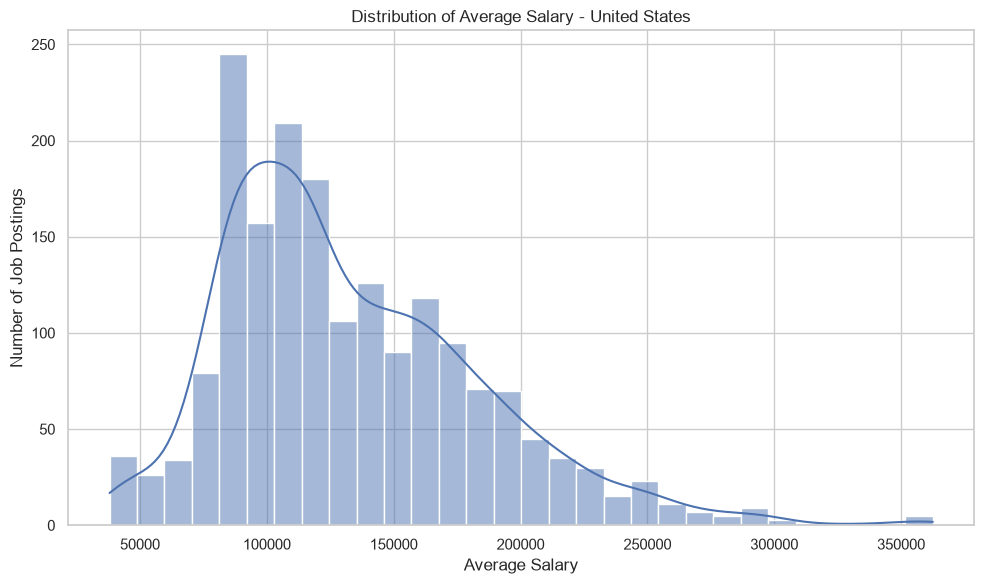

In [12]:
# Salary distribution

plt.figure(figsize=(10, 6))
sns.histplot(df_us_salary["salary_avg"], bins=30, kde=True)
plt.title("Distribution of Average Salary - United States")
plt.xlabel("Average Salary")
plt.ylabel("Number of Job Postings")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "salary_distribution_us.png", dpi=300, bbox_inches="tight")
plt.show()

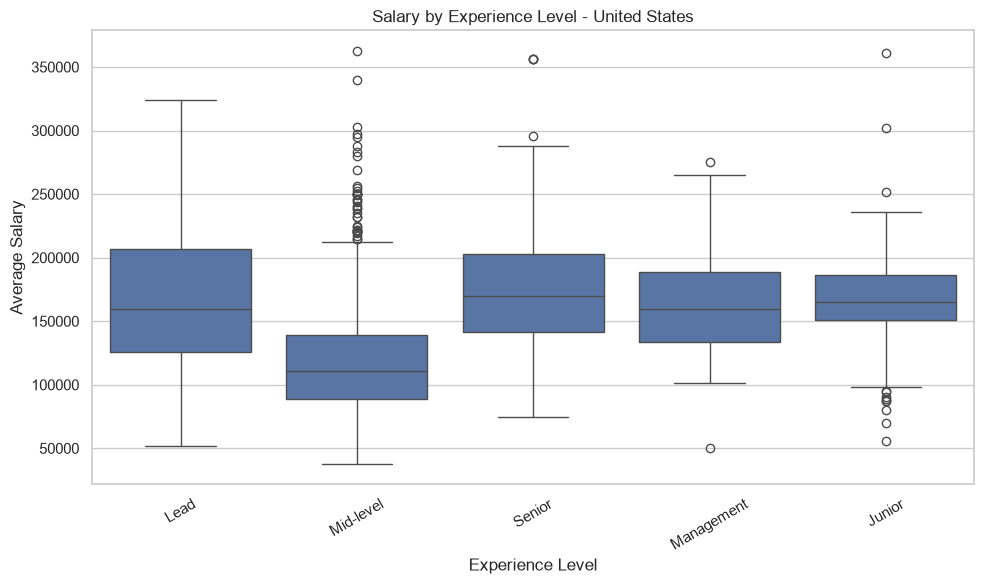

In [13]:
# Salary by experience level

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_us_salary,
    x="experience_level",
    y="salary_avg"
)
plt.title("Salary by Experience Level - United States")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "salary_by_experience_level_us.png", dpi=300, bbox_inches="tight")
plt.show()

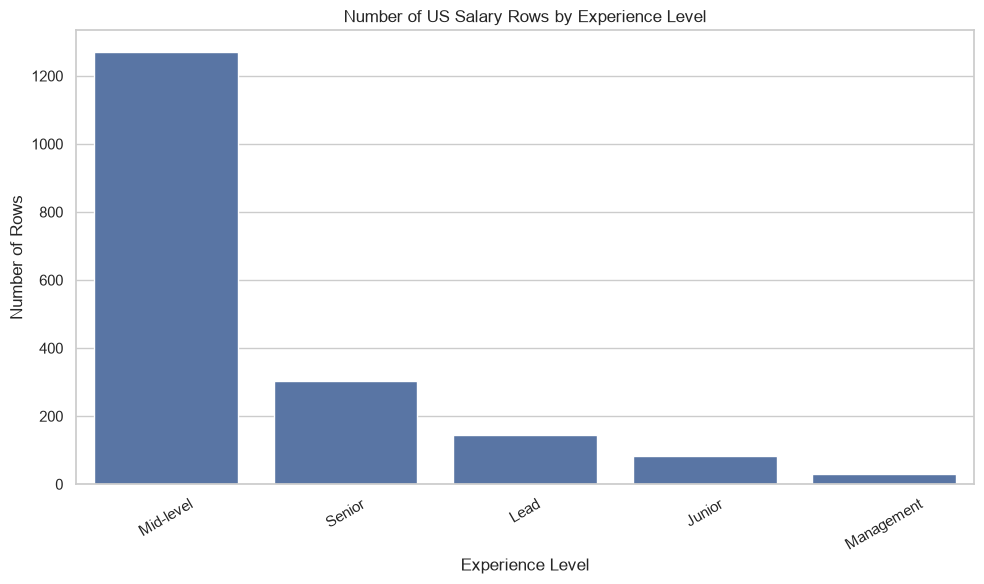

,experience_level,count
0,Mid-level,1270
1,Senior,304
2,Lead,145
3,Junior,83
4,Management,30


In [14]:
# Number of rows by experience level

experience_counts = (
    df_us_salary["experience_level"]
    .value_counts()
    .reset_index()
)
experience_counts.columns = ["experience_level", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=experience_counts, x="experience_level", y="count")
plt.title("Number of US Salary Rows by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Number of Rows")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "count_by_experience_level_us.png", dpi=300, bbox_inches="tight")
plt.show()

experience_counts

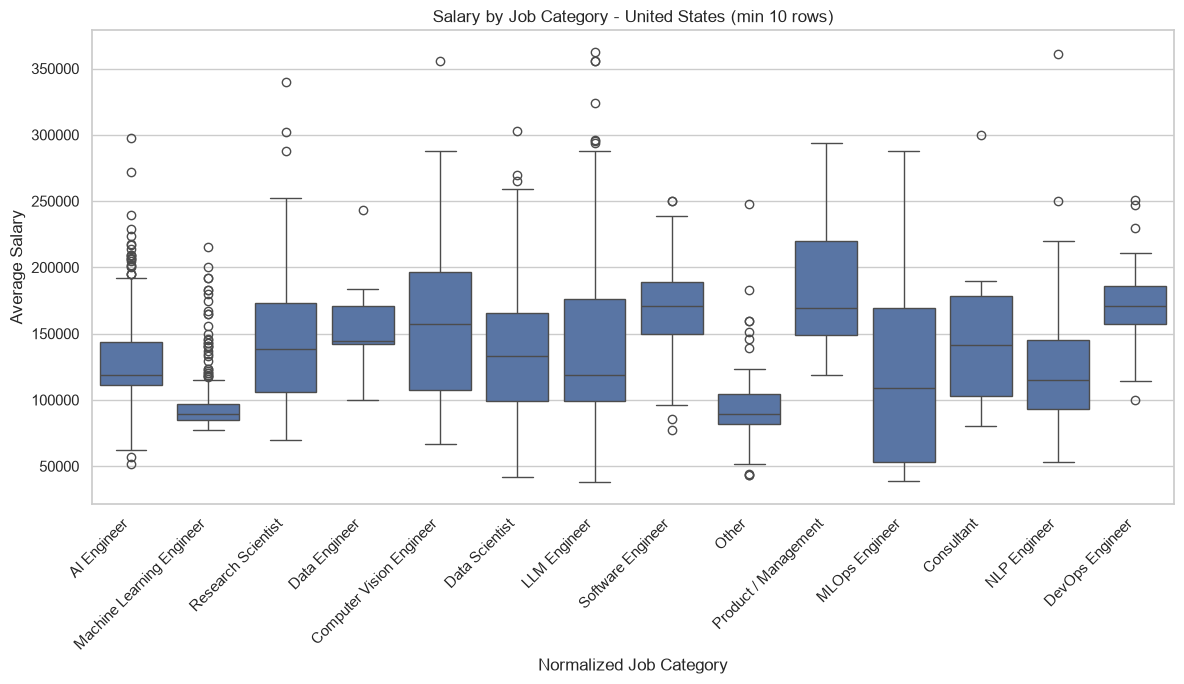

In [15]:
# Salary by normalized title

# Keep only categories with enough salary rows for a more reliable plot
min_rows = 10
valid_titles = df_us_salary["normalized_title"].value_counts()
valid_titles = valid_titles[valid_titles >= min_rows].index

salary_by_title_plot = df_us_salary[df_us_salary["normalized_title"].isin(valid_titles)].copy()

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=salary_by_title_plot,
    x="normalized_title",
    y="salary_avg"
)
plt.title(f"Salary by Job Category - United States (min {min_rows} rows)")
plt.xlabel("Normalized Job Category")
plt.ylabel("Average Salary")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "salary_by_normalized_title_us.png", dpi=300, bbox_inches="tight")
plt.show()

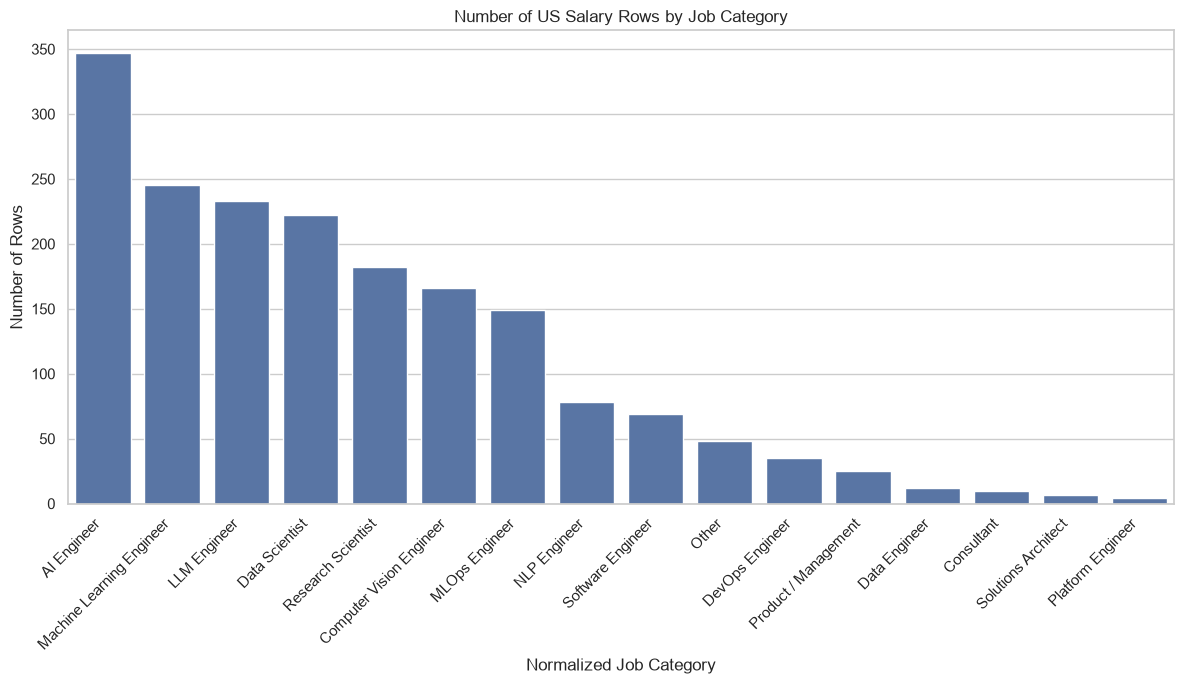

,normalized_title,count
0,AI Engineer,347
1,Machine Learning Engineer,245
2,LLM Engineer,233
3,Data Scientist,222
4,Research Scientist,182
5,Computer Vision Engineer,166
6,MLOps Engineer,149
7,NLP Engineer,78
8,Software Engineer,69
9,Other,48


In [16]:
# Number of rows by normalized title

title_counts = (
    df_us_salary["normalized_title"]
    .value_counts()
    .reset_index()
)
title_counts.columns = ["normalized_title", "count"]

plt.figure(figsize=(12, 7))
sns.barplot(data=title_counts.head(20), x="normalized_title", y="count")
plt.title("Number of US Salary Rows by Job Category")
plt.xlabel("Normalized Job Category")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "count_by_normalized_title_us.png", dpi=300, bbox_inches="tight")
plt.show()

title_counts.head(20)

## 5. Baseline Salary Model

A baseline model is a simple reference point.

Here, the baseline predicts the median salary for every row.

This is intentionally simple. Any real machine learning model should perform better than this baseline. If it does not, the model is probably not useful.

Metrics used:

- **MAE**: Mean Absolute Error. Average absolute prediction error. Easy to interpret in dollars.
- **RMSE**: Root Mean Squared Error. Penalizes large errors more strongly than MAE.
- **R²**: Proportion of variance explained. A value near 0 means the model is not much better than predicting the average. Negative values mean it is worse than a simple average-style prediction.

In [29]:
import sklearn
print(sklearn.__version__)

1.8.0


In [30]:
from sklearn.metrics import mean_squared_error

import inspect

print(mean_squared_error)
print(inspect.signature(mean_squared_error))

<function mean_squared_error at 0x000001BEC63DFE20>
(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')


In [31]:
import sklearn.metrics as metrics

print(metrics.mean_squared_error)
print(metrics.mean_squared_error.__module__)

<function mean_squared_error at 0x000001BEC63DFE20>
sklearn.metrics._regression


In [32]:
# Prepare target variable

y = df_us_salary["salary_avg"].copy()

# Train/test split for salary modeling
# We use the same split for all salary models.

train_index, test_index = train_test_split(
    df_us_salary.index,
    test_size=0.2,
    random_state=42
)

y_train = y.loc[train_index]
y_test = y.loc[test_index]

# Baseline prediction: median salary from the training set
baseline_prediction = np.full(shape=len(y_test), fill_value=y_train.median())

baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_rmse = mean_squared_error(y_test, baseline_prediction)
baseline_r2 = r2_score(y_test, baseline_prediction)

baseline_results = pd.DataFrame({
    "model": ["Baseline Median"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2]
})

baseline_results

,model,MAE,RMSE,R2
0,Baseline Median,39471.389646,2.796128e+09,-0.061412


## 6. Linear Regression Salary Model

Linear regression tries to learn a simple relationship between job features and salary.

In this notebook, the model uses:

- `normalized_title`
- `experience_level`
- `remote_type`
- recommended skills

Categorical variables are converted with one-hot encoding. Skills are converted into binary columns using `MultiLabelBinarizer`.

Salary prediction is noisy because compensation depends on many things that are not fully captured in job postings: company size, location cost, negotiation, benefits, stock compensation, industry, and whether the salary range is real or estimated.

This model is exploratory, not causal. If a feature is associated with higher salary, it does not prove that the feature causes higher salary.

In [33]:
# Select features for salary prediction

salary_features = ["normalized_title", "experience_level", "remote_type"]
skill_column = "recommended_skills_list"

df_salary_model = df_us_salary.loc[train_index.union(test_index)].copy()

X_train_base = df_salary_model.loc[train_index, salary_features].copy()
X_test_base = df_salary_model.loc[test_index, salary_features].copy()

skills_train = df_salary_model.loc[train_index, skill_column]
skills_test = df_salary_model.loc[test_index, skill_column]

# One-hot encode categorical variables
onehot = OneHotEncoder(handle_unknown="ignore")
X_train_cat = onehot.fit_transform(X_train_base)
X_test_cat = onehot.transform(X_test_base)

# Multi-hot encode skills
mlb = MultiLabelBinarizer()
X_train_skills = csr_matrix(mlb.fit_transform(skills_train))
X_test_skills = csr_matrix(mlb.transform(skills_test))

# Combine categorical features and skill features
X_train_salary = hstack([X_train_cat, X_train_skills])
X_test_salary = hstack([X_test_cat, X_test_skills])

print("Training matrix shape:", X_train_salary.shape)
print("Test matrix shape:", X_test_salary.shape)

Training matrix shape: (1465, 48)
Test matrix shape: (367, 48)


In [34]:
# Train a Linear Regression model on raw salary

linear_model = LinearRegression()
linear_model.fit(X_train_salary, y_train)

linear_pred = linear_model.predict(X_test_salary)

linear_results = pd.DataFrame({
    "model": ["Linear Regression"],
    "MAE": [mean_absolute_error(y_test, linear_pred)],
    "RMSE": [mean_squared_error(y_test, linear_pred)],
    "R2": [r2_score(y_test, linear_pred)]
})

linear_results

,model,MAE,RMSE,R2
0,Linear Regression,27909.416697,1.576810e+09,0.401442


### Log Salary Linear Regression

Salary is often skewed: a small number of high salaries can stretch the distribution.

Using `log_salary = np.log(salary_avg)` can sometimes make the target more stable.

After predicting log salary, we convert predictions back to dollars using `np.exp()`.

In [35]:
# Train a Linear Regression model on log salary

y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

log_linear_model = LinearRegression()
log_linear_model.fit(X_train_salary, y_train_log)

log_pred = log_linear_model.predict(X_test_salary)

# Convert predictions back to salary scale
log_linear_pred_salary = np.exp(log_pred)

log_linear_results = pd.DataFrame({
    "model": ["Log Linear Regression"],
    "MAE": [mean_absolute_error(y_test, log_linear_pred_salary)],
    "RMSE": [mean_squared_error(y_test, log_linear_pred_salary)],
    "R2": [r2_score(y_test, log_linear_pred_salary)]
})

log_linear_results

,model,MAE,RMSE,R2
0,Log Linear Regression,27983.469689,1.650388e+09,0.373511


## 7. Random Forest Salary Model

A Random Forest is an ensemble of decision trees.

Compared with Linear Regression, it can capture more complex and non-linear patterns. For example, it can learn that a skill may matter differently depending on job category or experience level.

However, Random Forest models can overfit, especially when the dataset is small. Results should still be interpreted carefully.

In [36]:
# Train a Random Forest Regressor

random_forest_regressor = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3,
    n_jobs=-1
)

random_forest_regressor.fit(X_train_salary, y_train)

rf_pred = random_forest_regressor.predict(X_test_salary)

rf_results = pd.DataFrame({
    "model": ["Random Forest Regressor"],
    "MAE": [mean_absolute_error(y_test, rf_pred)],
    "RMSE": [mean_squared_error(y_test, rf_pred)],
    "R2": [r2_score(y_test, rf_pred)]
})

rf_results

,model,MAE,RMSE,R2
0,Random Forest Regressor,26675.494177,1.598237e+09,0.393308


In [37]:
# Compare salary regression models

salary_regression_summary = pd.concat(
    [baseline_results, linear_results, log_linear_results, rf_results],
    ignore_index=True
)

salary_regression_summary.sort_values("MAE")

,model,MAE,RMSE,R2
3,Random Forest Regressor,26675.494177,1.598237e+09,0.393308
1,Linear Regression,27909.416697,1.576810e+09,0.401442
2,Log Linear Regression,27983.469689,1.650388e+09,0.373511
0,Baseline Median,39471.389646,2.796128e+09,-0.061412


### Random Forest Feature Importance

Feature importance gives a rough idea of which variables were useful to the Random Forest.

This is not the same as causality. A feature can be important because it is correlated with another factor, or because it appears frequently in certain job categories.

In [38]:
# Build feature names for interpretation

categorical_feature_names = onehot.get_feature_names_out(salary_features)
skill_feature_names = np.array(["skill_" + skill for skill in mlb.classes_])
all_feature_names = np.concatenate([categorical_feature_names, skill_feature_names])

rf_feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": random_forest_regressor.feature_importances_
}).sort_values("importance", ascending=False)

rf_feature_importance.head(30)

,feature,importance
19,experience_level_Mid-level,0.357267
30,skill_docker,0.063620
8,normalized_title_Machine Learning Engineer,0.063434
38,skill_nlp,0.037424
40,skill_python,0.030780
22,remote_type_Onsite,0.030360
28,skill_computer vision,0.030259
32,skill_gcp,0.024433
10,normalized_title_Other,0.023259
26,skill_aws,0.022877


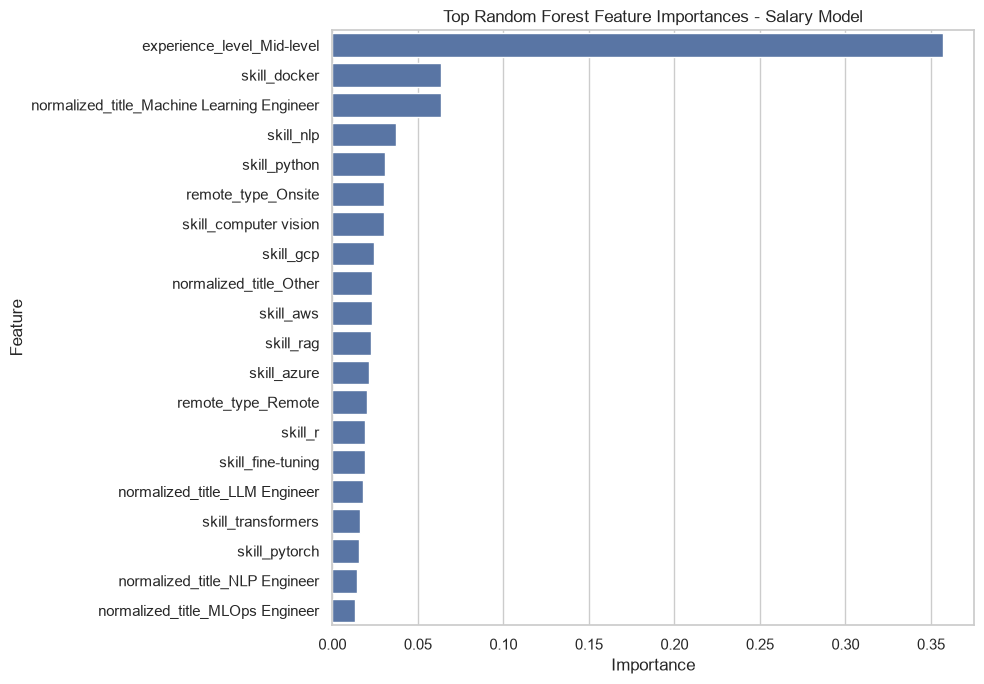

In [39]:
# Plot top feature importances

top_rf_features = rf_feature_importance.head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_rf_features, y="feature", x="importance")
plt.title("Top Random Forest Feature Importances - Salary Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "rf_salary_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Salary Band Classification

Predicting exact salary can be difficult and noisy.

An easier task is to predict salary bands. Here we split salaries into quartiles using `pd.qcut()`:

- Low
- Medium
- High
- Very High

This can be more stable than exact salary prediction because the model only needs to learn broad compensation groups instead of precise dollar amounts.

In [40]:
# Create salary bands using quartiles

df_us_salary["salary_band"] = pd.qcut(
    df_us_salary["salary_avg"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

print(df_us_salary["salary_band"].value_counts())

salary_band
Medium       468
Low          460
Very High    458
High         446
Name: count, dtype: int64


In [41]:
# Prepare train/test split for salary band classification

X_band = df_us_salary[salary_features].copy()
y_band = df_us_salary["salary_band"].astype(str)
skills_band = df_us_salary[skill_column]

X_band_train, X_band_test, y_band_train, y_band_test, skills_band_train, skills_band_test = train_test_split(
    X_band,
    y_band,
    skills_band,
    test_size=0.2,
    random_state=42,
    stratify=y_band
)

# Encode categorical features
onehot_band = OneHotEncoder(handle_unknown="ignore")
X_band_train_cat = onehot_band.fit_transform(X_band_train)
X_band_test_cat = onehot_band.transform(X_band_test)

# Encode skills
mlb_band = MultiLabelBinarizer()
X_band_train_skills = csr_matrix(mlb_band.fit_transform(skills_band_train))
X_band_test_skills = csr_matrix(mlb_band.transform(skills_band_test))

# Combine features
X_band_train_all = hstack([X_band_train_cat, X_band_train_skills])
X_band_test_all = hstack([X_band_test_cat, X_band_test_skills])

In [43]:
# Logistic Regression classifier

salary_band_logreg = LogisticRegression(max_iter=1000)
salary_band_logreg.fit(X_band_train_all, y_band_train)

band_logreg_pred = salary_band_logreg.predict(X_band_test_all)

print("Accuracy:",round(accuracy_score(y_band_test, band_logreg_pred), 3))
print("\nClassification report:")
print(classification_report(y_band_test, band_logreg_pred))

Accuracy: 0.512

Classification report:
              precision    recall  f1-score   support

        High       0.35      0.26      0.30        89
         Low       0.65      0.65      0.65        92
      Medium       0.55      0.61      0.58        94
   Very High       0.46      0.52      0.49        92

    accuracy                           0.51       367
   macro avg       0.50      0.51      0.50       367
weighted avg       0.50      0.51      0.50       367



In [45]:
# Random Forest classifier

salary_band_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=3,
    n_jobs=-1
)

salary_band_rf.fit(X_band_train_all, y_band_train)

band_rf_pred = salary_band_rf.predict(X_band_test_all)

print("Accuracy:", round(accuracy_score(y_band_test, band_rf_pred),3))
print("\nClassification report:")
print(classification_report(y_band_test, band_rf_pred))

Accuracy: 0.537

Classification report:
              precision    recall  f1-score   support

        High       0.33      0.28      0.30        89
         Low       0.71      0.67      0.69        92
      Medium       0.57      0.57      0.57        94
   Very High       0.51      0.61      0.55        92

    accuracy                           0.54       367
   macro avg       0.53      0.53      0.53       367
weighted avg       0.53      0.54      0.53       367



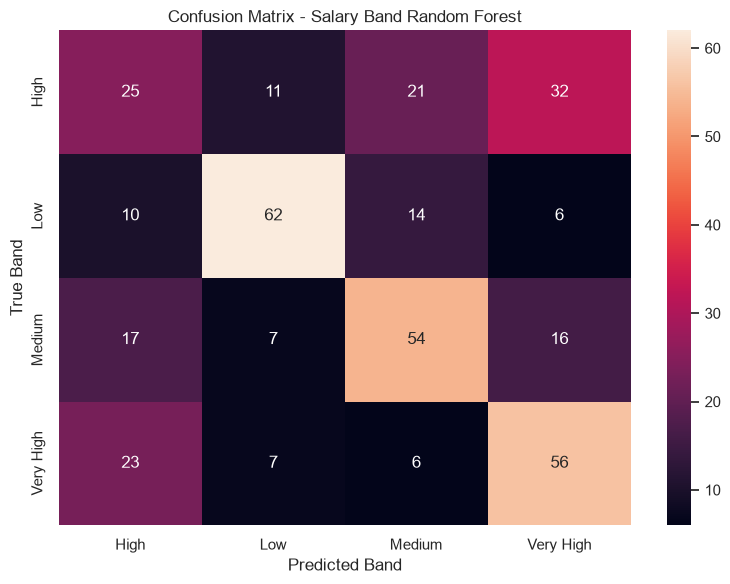

In [46]:
# Confusion matrix for the best salary band model
# You can change this to band_logreg_pred if Logistic Regression performs better.

salary_band_labels = sorted(y_band_test.unique())
cm_band = confusion_matrix(y_band_test, band_rf_pred, labels=salary_band_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_band,
    annot=True,
    fmt="d",
    xticklabels=salary_band_labels,
    yticklabels=salary_band_labels
)
plt.title("Confusion Matrix - Salary Band Random Forest")
plt.xlabel("Predicted Band")
plt.ylabel("True Band")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "salary_band_confusion_matrix_rf.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
# Save salary band model comparison

salary_classification_summary = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest Classifier"],
    "accuracy": [
        accuracy_score(y_band_test, band_logreg_pred),
        accuracy_score(y_band_test, band_rf_pred)
    ],
    "macro_f1": [
        f1_score(y_band_test, band_logreg_pred, average="macro"),
        f1_score(y_band_test, band_rf_pred, average="macro")
    ]
})

salary_classification_summary

,model,accuracy,macro_f1
0,Logistic Regression,0.512262,0.502744
1,Random Forest Classifier,0.536785,0.530875


## 9. Job Category Classification

This model predicts `normalized_title` from raw text:

- `job_title`
- `job_description`

This tests whether the job categories are learnable from the text itself.

This can be compared to the rule-based taxonomy used earlier. If the model struggles, it may mean that some job categories overlap or that job titles are ambiguous.

In [48]:
# Prepare text classification dataset

category_data = df_ml.copy()

category_data["job_title"] = category_data["job_title"].fillna("").astype(str)
category_data["job_description"] = category_data["job_description"].fillna("").astype(str)
category_data["normalized_title"] = category_data["normalized_title"].fillna("Unknown").astype(str)

# Combine title and description into one text column
category_data["text"] = (
    category_data["job_title"] + " " + category_data["job_description"]
)

# Remove very rare classes because they are hard to evaluate with train/test split
min_category_count = 5
category_counts = category_data["normalized_title"].value_counts()
valid_categories = category_counts[category_counts >= min_category_count].index

category_data = category_data[category_data["normalized_title"].isin(valid_categories)].copy()

print("Category classification dataset shape:", category_data.shape)
print("Number of categories:", category_data["normalized_title"].nunique())

Category classification dataset shape: (5773, 49)
Number of categories: 16


In [50]:
# Train/test split

X_text = category_data["text"]
y_category = category_data["normalized_title"]

X_text_train, X_text_test, y_category_train, y_category_test = train_test_split(
    X_text,
    y_category,
    test_size=0.2,
    random_state=42,
    stratify=y_category
)

# Create a simple text classification pipeline
category_classifier = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        stop_words="english",
        ngram_range=(1, 2)
    )),
    ("model", LogisticRegression(max_iter=1000))
])

category_classifier.fit(X_text_train, y_category_train)

category_pred = category_classifier.predict(X_text_test)

print("Accuracy:", round(accuracy_score(y_category_test, category_pred),3))
print("\nClassification report:")
print(classification_report(y_category_test, category_pred))

Accuracy: 0.802

Classification report:
                           precision    recall  f1-score   support

              AI Engineer       0.70      0.95      0.81       266
 Computer Vision Engineer       0.98      0.94      0.96        48
               Consultant       1.00      0.39      0.56        23
            Data Engineer       0.91      0.43      0.59        23
           Data Scientist       0.86      0.98      0.92       194
          DevOps Engineer       1.00      0.21      0.35        14
             LLM Engineer       0.92      0.73      0.82        79
           MLOps Engineer       0.91      0.84      0.88        50
Machine Learning Engineer       0.84      0.88      0.86       165
             NLP Engineer       1.00      0.57      0.72        23
                    Other       0.47      0.21      0.29        33
        Platform Engineer       0.60      0.25      0.35        12
     Product / Management       0.65      0.59      0.62        44
       Research Scien

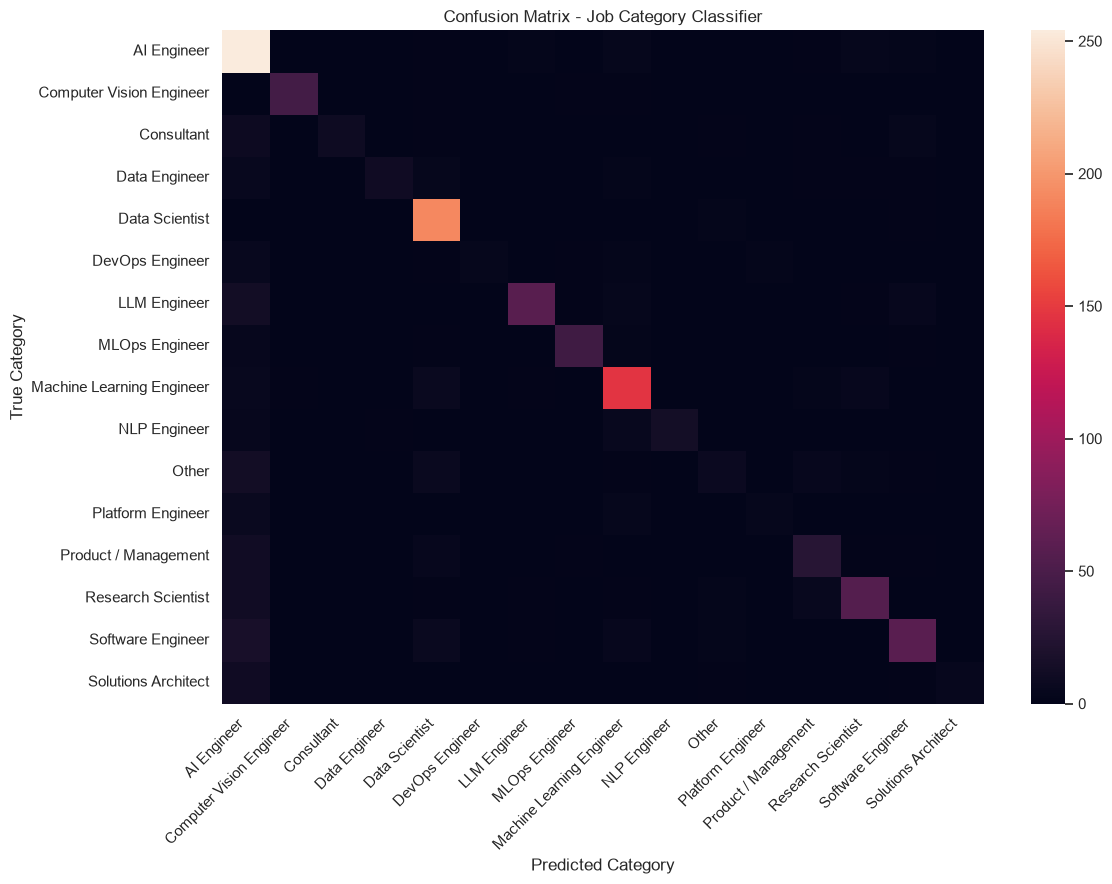

In [51]:
# Confusion matrix for job category classification

category_labels = sorted(y_category_test.unique())
cm_category = confusion_matrix(y_category_test, category_pred, labels=category_labels)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm_category,
    annot=False,
    xticklabels=category_labels,
    yticklabels=category_labels
)
plt.title("Confusion Matrix - Job Category Classifier")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "job_category_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [52]:
# Store category classifier summary

job_category_summary = pd.DataFrame({
    "model": ["TF-IDF + Logistic Regression"],
    "accuracy": [accuracy_score(y_category_test, category_pred)],
    "macro_f1": [f1_score(y_category_test, category_pred, average="macro")]
})

job_category_summary

,model,accuracy,macro_f1
0,TF-IDF + Logistic Regression,0.801732,0.664345


## 10. Skill Prediction as Multi-Label Classification

This model tries to predict `recommended_skills_list` from:

- `job_title`
- `job_description`
- `normalized_title`

This is a multi-label classification problem because one job can have many skills.

Important limitation: this model learns to reproduce the final recommended skill signal. It does not discover absolute truth. The labels come from the previous KNN + LLM + rescue pipeline, so they may contain noise.

Metrics used:

- **Micro F1**: measures overall skill prediction quality across all labels. Frequent skills have more influence.
- **Macro F1**: averages F1 across skills. Rare skills have more influence, so this score is usually lower.
- **Hamming loss**: fraction of incorrect labels. Lower is better.

In [53]:
# Prepare data for skill prediction

skill_data = df_ml.copy()

skill_data["job_title"] = skill_data["job_title"].fillna("").astype(str)
skill_data["job_description"] = skill_data["job_description"].fillna("").astype(str)
skill_data["normalized_title"] = skill_data["normalized_title"].fillna("Unknown").astype(str)

# Make sure recommended_skills_list is parsed
skill_data["recommended_skills_list"] = skill_data["recommended_skills_list"].apply(parse_skill_list)

# Keep rows with at least one recommended skill
skill_data = skill_data[skill_data["recommended_skills_list"].apply(len) > 0].copy()

# Combine text fields
skill_data["skill_text"] = (
    skill_data["job_title"] + " " +
    skill_data["normalized_title"] + " " +
    skill_data["job_description"]
)

print("Skill prediction dataset shape:", skill_data.shape)

Skill prediction dataset shape: (4998, 49)


In [54]:
# Optional: keep only skills that appear often enough
# This makes the task more realistic and avoids training on extremely rare labels.

all_skills = skill_data["recommended_skills_list"].explode()
skill_counts = all_skills.value_counts()

min_skill_count = 10
common_skills = set(skill_counts[skill_counts >= min_skill_count].index)

skill_data["common_recommended_skills"] = skill_data["recommended_skills_list"].apply(
    lambda skills: [skill for skill in skills if skill in common_skills]
)

skill_data = skill_data[skill_data["common_recommended_skills"].apply(len) > 0].copy()

print("Skill prediction dataset after rare skill filtering:", skill_data.shape)
print("Number of common skills:", len(common_skills))

Skill prediction dataset after rare skill filtering: (4998, 50)
Number of common skills: 22


In [55]:
# Train/test split for multi-label skill prediction

X_skill_text = skill_data["skill_text"]
y_skill_lists = skill_data["common_recommended_skills"]

X_skill_train, X_skill_test, y_skill_train_lists, y_skill_test_lists = train_test_split(
    X_skill_text,
    y_skill_lists,
    test_size=0.2,
    random_state=42
)

# Convert skill lists into binary matrix
skill_mlb = MultiLabelBinarizer()
y_skill_train = skill_mlb.fit_transform(y_skill_train_lists)
y_skill_test = skill_mlb.transform(y_skill_test_lists)

# TF-IDF vectorization
skill_tfidf = TfidfVectorizer(
    max_features=8000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_skill_train_tfidf = skill_tfidf.fit_transform(X_skill_train)
X_skill_test_tfidf = skill_tfidf.transform(X_skill_test)

print("Text matrix shape:", X_skill_train_tfidf.shape)
print("Skill label matrix shape:", y_skill_train.shape)

Text matrix shape: (3998, 8000)
Skill label matrix shape: (3998, 22)


In [56]:
# Multi-label classifier

skill_classifier = OneVsRestClassifier(
    LogisticRegression(max_iter=1000)
)

skill_classifier.fit(X_skill_train_tfidf, y_skill_train)

skill_pred = skill_classifier.predict(X_skill_test_tfidf)

skill_micro_f1 = f1_score(y_skill_test, skill_pred, average="micro", zero_division=0)
skill_macro_f1 = f1_score(y_skill_test, skill_pred, average="macro", zero_division=0)
skill_hamming = hamming_loss(y_skill_test, skill_pred)

skill_prediction_summary = pd.DataFrame({
    "model": ["TF-IDF + OneVsRest Logistic Regression"],
    "micro_f1": [skill_micro_f1],
    "macro_f1": [skill_macro_f1],
    "hamming_loss": [skill_hamming]
})

skill_prediction_summary

,model,micro_f1,macro_f1,hamming_loss
0,TF-IDF + OneVsRest Logistic Regression,0.663884,0.391865,0.069545


In [57]:
# Show a few example predictions

example_count = 10
example_texts = X_skill_test.iloc[:example_count]
example_true = y_skill_test[:example_count]
example_pred = skill_pred[:example_count]

examples = []

for i in range(example_count):
    true_skills = skill_mlb.inverse_transform(example_true[i].reshape(1, -1))[0]
    pred_skills = skill_mlb.inverse_transform(example_pred[i].reshape(1, -1))[0]
    
    examples.append({
        "text_preview": example_texts.iloc[i][:200],
        "true_skills": ", ".join(true_skills),
        "predicted_skills": ", ".join(pred_skills)
    })

pd.DataFrame(examples)

,text_preview,true_skills,predicted_skills
0,"AI Engineer AI Engineer Our company: At Teradata, we believe that people thrive when empowered with better informati...","azure, rag","azure, rag"
1,Computer Vision Research Engineer (Biometric Platform) Computer Vision Engineer Computer Vision Research Engineer Ab...,computer vision,computer vision
2,Senior AI/ML Engineer (Remote) Machine Learning Engineer About vidIQ vidIQ builds software to help YouTube creators ...,"aws, computer vision",aws
3,ENGINEER/SCIENTIST (Lead Test and Evaluation Engineer) Software Engineer Your resume must demonstrate at least one y...,"aws, python, r",python
4,"Applied Scientist, Data Science Data Scientist Who we are Prior Labs is building foundation models that understand t...","computer vision, langchain, python, r, transformers","python, r"
5,Senior AI Platform Engineer (Multi-tenant SaaS & MLOps) MLOps Engineer Senior AI Platform Engineer (Multi-tenant Saa...,"aws, kubernetes, python","aws, kubernetes, python"
6,"Distinguished AI Engineer AI Engineer Distinguished AI Engineer Overview: At Capital One, we are creating responsibl...","azure, python, rag","python, rag"
7,"Agentic AI/Python Lead Engineer (API, Microservices, LLM) - Senior Lead Software Engineer LLM Engineer We are buildi...",python,python
8,Consultant for Digital Transformation & AI – Ideal for Career Changer Consultant mycareernow GmbH mycareernow ist ei...,"azure, nlp, r","azure, nlp, r"
9,"Computer Vision Software Engineer Computer Vision Engineer Computer Vision Software Engineer | Silgan | Waukegan, IL...",computer vision,computer vision


## 11. Job Clustering and Market Segmentation

Clustering is an unsupervised learning method.

Unlike classification, there is no target label. The algorithm groups similar job postings based on their text and skills.

This can help reveal market segments such as:

- GenAI / LLM roles
- Data Science roles
- Computer Vision roles
- MLOps / Cloud roles
- Software / Platform roles

The cluster names are not automatically known. We interpret them by looking at top job categories, top skills, and sample job titles.

In [58]:
# Prepare clustering dataset

cluster_data = df_ml.copy()

cluster_data["job_title"] = cluster_data["job_title"].fillna("").astype(str)
cluster_data["job_description"] = cluster_data["job_description"].fillna("").astype(str)
cluster_data["normalized_title"] = cluster_data["normalized_title"].fillna("Unknown").astype(str)
cluster_data["recommended_skills_list"] = cluster_data["recommended_skills_list"].apply(parse_skill_list)

cluster_data["skills_text"] = cluster_data["recommended_skills_list"].apply(lambda skills: " ".join(skills))

cluster_data["cluster_text"] = (
    cluster_data["job_title"] + " " +
    cluster_data["normalized_title"] + " " +
    cluster_data["skills_text"] + " " +
    cluster_data["job_description"]
)

print("Clustering dataset shape:", cluster_data.shape)

Clustering dataset shape: (5773, 50)


In [59]:
# Vectorize text using TF-IDF

cluster_tfidf = TfidfVectorizer(
    max_features=8000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_cluster = cluster_tfidf.fit_transform(cluster_data["cluster_text"])

print("TF-IDF matrix shape:", X_cluster.shape)

TF-IDF matrix shape: (5773, 8000)


In [60]:
# KMeans clustering

n_clusters = 6

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

cluster_data["cluster"] = kmeans.fit_predict(X_cluster)

cluster_data["cluster"].value_counts().sort_index()

cluster
0     177
1     560
2     198
3     436
4     940
5    3462
Name: count, dtype: int64

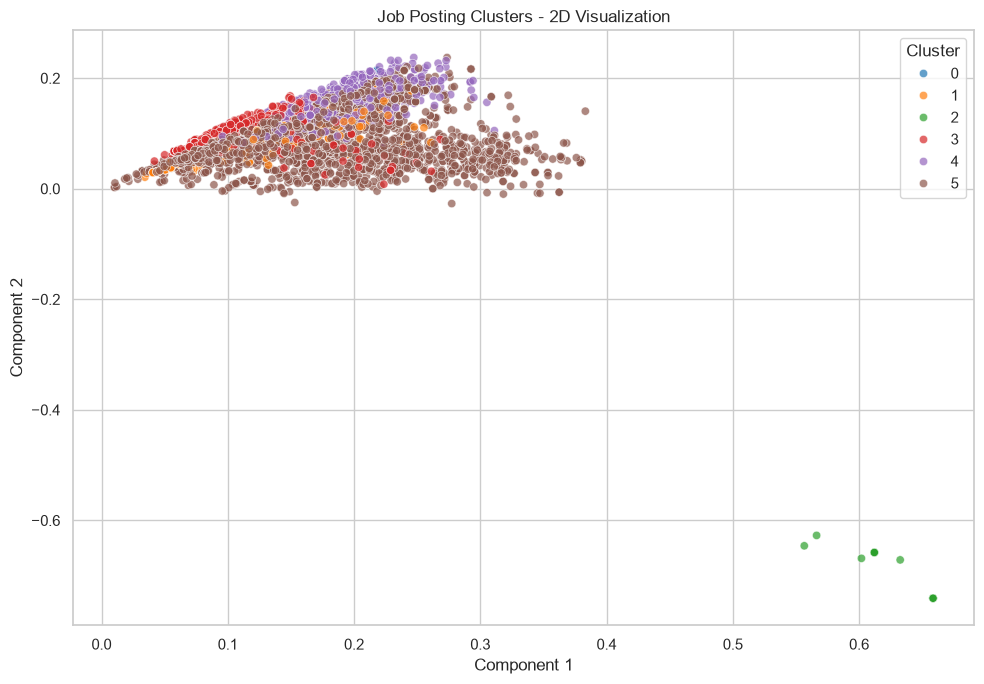

In [61]:
# Reduce dimensions for 2D visualization using TruncatedSVD
# TruncatedSVD works well with sparse TF-IDF matrices.

svd = TruncatedSVD(n_components=2, random_state=42)
cluster_2d = svd.fit_transform(X_cluster)

cluster_data["cluster_x"] = cluster_2d[:, 0]
cluster_data["cluster_y"] = cluster_2d[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=cluster_data,
    x="cluster_x",
    y="cluster_y",
    hue="cluster",
    palette="tab10",
    alpha=0.7
)
plt.title("Job Posting Clusters - 2D Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "job_clusters_2d.png", dpi=300, bbox_inches="tight")
plt.show()

In [62]:
# Cluster size summary

cluster_summary = (
    cluster_data["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)
cluster_summary.columns = ["cluster", "job_count"]

cluster_summary

,cluster,job_count
0,0,177
1,1,560
2,2,198
3,3,436
4,4,940
5,5,3462


In [63]:
# Inspect clusters: top categories, top skills, sample job titles

cluster_profiles = []

for cluster_id in sorted(cluster_data["cluster"].unique()):
    subset = cluster_data[cluster_data["cluster"] == cluster_id]
    
    top_categories = subset["normalized_title"].value_counts().head(5)
    top_titles = subset["job_title"].dropna().head(8).tolist()
    top_skills = subset["recommended_skills_list"].explode().value_counts().head(10)
    
    cluster_profiles.append({
        "cluster": cluster_id,
        "job_count": len(subset),
        "top_categories": "; ".join([f"{idx} ({val})" for idx, val in top_categories.items()]),
        "top_skills": "; ".join([f"{idx} ({val})" for idx, val in top_skills.items()]),
        "sample_job_titles": "; ".join(top_titles)
    })

cluster_profiles_df = pd.DataFrame(cluster_profiles)
cluster_profiles_df

,cluster,job_count,top_categories,top_skills,sample_job_titles
0,0,177,AI Engineer (177),fine-tuning (144); nlp (144); rag (144); python (131); azure (98); transformers (98); openai (98); langchain (46); d...,AI Engineer; AI Engineer; AI Engineer; AI Engineer; AI Engineer; AI Engineer; AI Engineer; AI Engineer
1,1,560,Software Engineer (373); AI Engineer (56); DevOps Engineer (33); LLM Engineer (29); Product / Management (17),python (337); aws (168); azure (128); kubernetes (120); openai (112); rag (110); nlp (61); computer vision (50); r (...,"Kubernetes AI Engineer; Generative AI Engineer with Security Clearance; Software Engineer, LLM & Automation; Softwar..."
2,2,198,Machine Learning Engineer (196); Data Scientist (1); AI Engineer (1),computer vision (195); nlp (195); r (176); kubernetes (21); python (2); spark (1); aws (1),Machine Learning Engineer (PhD Intern); Machine Learning Engineer (PhD Intern); Machine Learning Engineer (PhD Inter...
3,3,436,AI Engineer (117); Data Scientist (101); LLM Engineer (44); Machine Learning Engineer (32); Consultant (29),azure (161); nlp (137); python (132); r (121); rag (116); aws (81); computer vision (65); gcp (35); openai (28); kub...,AI & Medical Data Engineer; Senior AI Engineer; Senior AI Engineer; AI Engineer Translation Management; Azure AI Eng...
4,4,940,Data Scientist (804); Research Scientist (94); Data Engineer (26); NLP Engineer (4); MLOps Engineer (3),r (713); python (513); computer vision (370); aws (321); nlp (254); azure (222); gcp (129); rag (66); spark (36); da...,Data Scientist; Data Scientist; Senior Data Scientist; Data Scientist; GEOINT Data Scientist; GEOINT Data Scientist;...
5,5,3462,AI Engineer (976); Machine Learning Engineer (591); LLM Engineer (323); Research Scientist (281); Computer Vision En...,python (1352); nlp (992); azure (871); rag (757); computer vision (747); aws (681); fine-tuning (411); r (366); tran...,AI Engineer; AI Engineer; AI Engineer; Frontend/AI Engineer; AI Engineering Lead; Agentic AI Engineer; Agentic AI En...


### Interpreting Clusters

Use the table above to manually interpret each cluster.

A careful interpretation should avoid overclaiming. For example:

- If a cluster contains many `LLM`, `RAG`, `LangChain`, or `OpenAI` skills, it may represent a GenAI / LLM segment.
- If a cluster contains many `SQL`, `Spark`, `Airflow`, or cloud tools, it may represent Data Engineering.
- If a cluster contains `Docker`, `Kubernetes`, `AWS`, or `MLOps`, it may represent ML infrastructure or platform roles.
- If the cluster is mixed, that is also useful: it means the market does not always separate cleanly into ideal categories.

## 12. Model Comparison Summary

This section gathers model results into clean summary tables.

These tables are useful for a portfolio because they show that the models were evaluated against clear metrics instead of only trained.

In [64]:
# Salary regression summary

salary_regression_summary = salary_regression_summary.round(3)
salary_regression_summary

,model,MAE,RMSE,R2
0,Baseline Median,39471.390,2.796128e+09,-0.061
1,Linear Regression,27909.417,1.576810e+09,0.401
2,Log Linear Regression,27983.470,1.650388e+09,0.374
3,Random Forest Regressor,26675.494,1.598237e+09,0.393


In [65]:
# Salary classification summary

salary_classification_summary = salary_classification_summary.round(3)
salary_classification_summary

,model,accuracy,macro_f1
0,Logistic Regression,0.512,0.503
1,Random Forest Classifier,0.537,0.531


In [66]:
# Job category classifier summary

job_category_summary = job_category_summary.round(3)
job_category_summary

,model,accuracy,macro_f1
0,TF-IDF + Logistic Regression,0.802,0.664


In [67]:
# Skill prediction summary

skill_prediction_summary = skill_prediction_summary.round(3)
skill_prediction_summary

,model,micro_f1,macro_f1,hamming_loss
0,TF-IDF + OneVsRest Logistic Regression,0.664,0.392,0.07


# 13. Final Interpretation

## Overview

This notebook explored several machine learning approaches on a real-world AI job market dataset containing more than 5,700 job postings.

The objective was not to build production-grade predictive systems, but rather to evaluate how much useful information can be extracted from job titles, descriptions, job categories, and inferred skills using standard machine learning techniques.

The results demonstrate that some aspects of the AI job market are highly predictable from text, while others remain inherently noisy.

---

## Salary Prediction Results

### What worked well

The salary regression models significantly outperformed the baseline model.

| Model                 | MAE    | R²    |
| --------------------- | ------ | ----- |
| Baseline Median       | 39,471 | -0.06 |
| Linear Regression     | 27,909 | 0.40  |
| Log Linear Regression | 27,983 | 0.37  |
| Random Forest         | 26,675 | 0.39  |

The baseline model simply predicted the median salary for every job posting.

Both Linear Regression and Random Forest reduced prediction error substantially and explained approximately 40% of the observed salary variation.

For a dataset containing only job metadata, inferred skills, and job descriptions, this represents a meaningful signal.

### What did not work well

Salary prediction remains difficult because compensation depends on many factors that are not available in the dataset, including:

* company size
* stock compensation
* bonuses
* geographic salary adjustments
* industry sector
* negotiation outcomes
* internal compensation policies

As a result, more than half of salary variation remains unexplained.

These models should therefore be viewed as exploratory tools rather than accurate salary forecasting systems.

---

## Salary Band Classification

Instead of predicting exact salaries, the notebook also predicted salary quartiles:

* Low
* Medium
* High
* Very High

Results:

| Model               | Accuracy |
| ------------------- | -------- |
| Logistic Regression | 51.2%    |
| Random Forest       | 53.7%    |

Since random guessing would achieve approximately 25% accuracy, both models capture meaningful salary-related information.

The confusion matrix shows that most mistakes occur between neighboring salary bands rather than extreme categories.

For example:

* High salaries are often confused with Very High salaries
* Medium salaries are often confused with High salaries

This suggests that salary band prediction may be more realistic and useful than attempting to predict exact compensation values.

---

## Job Category Classification

The strongest result in the notebook comes from job category prediction.

The model used:

* job title
* job description
* TF-IDF features
* Logistic Regression

Results:

| Metric   | Value |
| -------- | ----- |
| Accuracy | 80.2% |
| Macro F1 | 0.66  |

Several categories achieved very high performance:

* Computer Vision Engineer
* Data Scientist
* Machine Learning Engineer
* MLOps Engineer

These results indicate that the normalized taxonomy developed earlier captures meaningful information present in job titles and descriptions.

The model struggles primarily with smaller and more ambiguous categories such as:

* Consultant
* Platform Engineer
* Solutions Architect
* DevOps Engineer

This is expected because these categories contain fewer examples and often overlap with other roles.

Overall, the results suggest that AI job categories are highly learnable from text.

---

## Skill Prediction

The multi-label skill prediction model attempted to reproduce the final recommended skill lists generated during the previous enrichment pipeline.

Results:

| Metric       | Value |
| ------------ | ----- |
| Micro F1     | 0.664 |
| Macro F1     | 0.392 |
| Hamming Loss | 0.070 |

Several example predictions matched the target skills exactly.

The model frequently recovered skills such as:

* Python
* AWS
* Azure
* RAG
* Kubernetes
* Computer Vision

This result suggests that job titles and descriptions contain enough information to recover a substantial portion of the enriched skill signal.

However, it is important to remember that the model is learning the output of the enrichment pipeline rather than discovering objective ground truth.

The labels themselves originate from:

* original skills
* KNN skill inference
* LLM validation
* rescue logic

Therefore, any noise present in the enrichment process may also appear in the predictions.

---

## Clustering and Market Segmentation

K-Means clustering was used to explore whether natural groups emerge within the AI job market.

Several meaningful clusters appeared:

### Cluster 0

Likely represents:

* Generative AI
* RAG systems
* LangChain
* Fine-tuning
* OpenAI-related roles

### Cluster 1

Likely represents:

* Software Engineering
* Platform Engineering
* DevOps
* Infrastructure-focused AI roles

### Cluster 2

Likely represents:

* Machine Learning
* Computer Vision

### Cluster 4

Likely represents:

* Data Science
* Research

However, clustering quality was mixed.

One cluster contained more than half of all job postings, suggesting that the market does not naturally separate into a small number of clean segments.

This result highlights an important characteristic of AI careers: many roles overlap substantially in terms of skills and responsibilities.

---

## Key Insights

Several observations emerge from the analysis:

1. Experience level is the strongest salary-related feature.

2. Skills such as Python, Docker, NLP, Computer Vision, and cloud technologies frequently appear among higher-paying roles.

3. AI job categories are highly predictable from text descriptions.

4. Skill requirements are partially recoverable from job descriptions.

5. Salary prediction remains difficult because many compensation drivers are not present in job postings.

6. The AI job market contains meaningful specialization, but role boundaries are often blurry.

---

## Dataset Limitations

Several important limitations should be considered when interpreting results:

* Many job descriptions are truncated.
* Salary information is missing for a large portion of postings.
* Salaries should not be compared across countries without currency normalization.
* Recommended skills are enriched signals rather than direct employer requirements.
* Inferred labels may contain noise.
* Some categories naturally overlap, particularly AI Engineer, Machine Learning Engineer, MLOps Engineer, Software Engineer, and Data Scientist roles.

---

## Final Conclusion

The machine learning models successfully extracted useful signals from the dataset.

The strongest results were obtained for:

* job category classification
* skill prediction

Salary prediction produced meaningful but imperfect results, reflecting the complexity of real-world compensation systems.

Overall, the project demonstrates a complete applied machine learning workflow:

* data preparation
* exploratory analysis
* regression
* classification
* multi-label learning
* clustering
* model evaluation
* result interpretation

The primary value of this notebook is not building a perfect predictive system, but demonstrating how machine learning can be applied to understand patterns in the AI job market using real-world data.


## 14. Save Outputs

Finally, we save the main datasets, model comparison tables, reports, feature importance tables, clustering results, and trained models.

Saving outputs makes the project reproducible and easier to reuse in a report, GitHub repository, or portfolio post.

In [68]:
# Save cleaned ML datasets

df_ml.to_csv(TABLE_DIR / "ml_working_dataset.csv", index=False)
df_us_salary.to_csv(TABLE_DIR / "us_salary_ml_dataset.csv", index=False)
cluster_data.to_csv(TABLE_DIR / "job_clustering_results.csv", index=False)

print("Saved cleaned datasets.")

Saved cleaned datasets.


In [69]:
# Save model comparison tables

salary_regression_summary.to_csv(TABLE_DIR / "salary_regression_model_comparison.csv", index=False)
salary_classification_summary.to_csv(TABLE_DIR / "salary_classification_model_comparison.csv", index=False)
job_category_summary.to_csv(TABLE_DIR / "job_category_classifier_summary.csv", index=False)
skill_prediction_summary.to_csv(TABLE_DIR / "skill_prediction_summary.csv", index=False)

print("Saved model comparison tables.")

Saved model comparison tables.


In [70]:
# Save classification reports as CSV files

salary_band_rf_report = pd.DataFrame(
    classification_report(y_band_test, band_rf_pred, output_dict=True)
).transpose()

job_category_report = pd.DataFrame(
    classification_report(y_category_test, category_pred, output_dict=True)
).transpose()

salary_band_rf_report.to_csv(TABLE_DIR / "salary_band_random_forest_classification_report.csv")
job_category_report.to_csv(TABLE_DIR / "job_category_classification_report.csv")

print("Saved classification reports.")

Saved classification reports.


In [71]:
# Save feature importance and cluster profiles

rf_feature_importance.to_csv(TABLE_DIR / "random_forest_salary_feature_importance.csv", index=False)
cluster_profiles_df.to_csv(TABLE_DIR / "cluster_profiles.csv", index=False)

print("Saved feature importance and cluster profiles.")

Saved feature importance and cluster profiles.


In [72]:
# Save selected models and preprocessing objects
# These files can be reused later without retraining.

joblib.dump(random_forest_regressor, MODEL_DIR / "random_forest_salary_regressor.joblib")
joblib.dump(onehot, MODEL_DIR / "salary_onehot_encoder.joblib")
joblib.dump(mlb, MODEL_DIR / "salary_skill_binarizer.joblib")

joblib.dump(category_classifier, MODEL_DIR / "job_category_classifier.joblib")

joblib.dump(skill_classifier, MODEL_DIR / "skill_classifier.joblib")
joblib.dump(skill_tfidf, MODEL_DIR / "skill_tfidf_vectorizer.joblib")
joblib.dump(skill_mlb, MODEL_DIR / "skill_multilabel_binarizer.joblib")

joblib.dump(kmeans, MODEL_DIR / "job_kmeans_clustering_model.joblib")
joblib.dump(cluster_tfidf, MODEL_DIR / "cluster_tfidf_vectorizer.joblib")
joblib.dump(svd, MODEL_DIR / "cluster_svd_2d_model.joblib")

print("Saved models and preprocessing objects.")

Saved models and preprocessing objects.


# End of Notebook

This notebook completes the machine learning section of the AI job market analysis project.

The results should be interpreted carefully and honestly. The main value is not perfect prediction, but a clean demonstration of applied machine learning on a real job market dataset.